
📊 HistGradientBoosting Performance:
MSE: 0.000042
MAPE: 39470517182.789314
R²: 0.623813
Adjusted R²: 0.619808


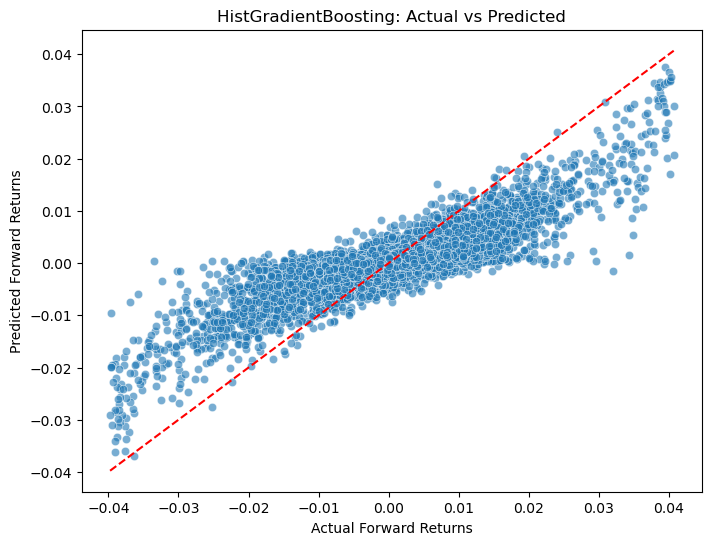

In [11]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_percentage_error, r2_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# STEP 1: Load train data
train = pd.read_csv(r"D:\sem project\train.csv")
train = train.ffill().fillna(0)
drop_cols = ["forward_returns", "risk_free_rate", "market_forward_excess_returns"]
X_train = train.drop(columns=[c for c in drop_cols if c in train.columns])
y_train = train["forward_returns"]

# STEP 2: Train HistGradientBoosting
model = HistGradientBoostingRegressor(
    max_iter=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)
model.fit(X_train, y_train)

# STEP 3: Load test data
test = pd.read_csv(r"D:\sem project\test.csv")
test = test.ffill().fillna(0)
extra_cols = set(test.columns) - set(X_train.columns)
test = test.drop(columns=list(extra_cols))
X_test = test[X_train.columns]

# STEP 4: Predict allocations
test_preds = model.predict(X_test)
allocations = 1 + test_preds / test_preds.std()
allocations = allocations.clip(0, 2)

# STEP 5: Evaluation
y_pred_train = model.predict(X_train)
mse = mean_squared_error(y_train, y_pred_train)
mape = mean_absolute_percentage_error(y_train, y_pred_train)
r2 = r2_score(y_train, y_pred_train)
n, p = X_train.shape
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("\n📊 HistGradientBoosting Performance:")
print(f"MSE: {mse:.6f}")
print(f"MAPE: {mape:.6f}")
print(f"R²: {r2:.6f}")
print(f"Adjusted R²: {adj_r2:.6f}")

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_train, y=y_pred_train, alpha=0.6)
plt.xlabel("Actual Forward Returns")
plt.ylabel("Predicted Forward Returns")
plt.title("HistGradientBoosting: Actual vs Predicted")
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
plt.show()


  0%|          | 0/50 [00:00<?, ?it/s]

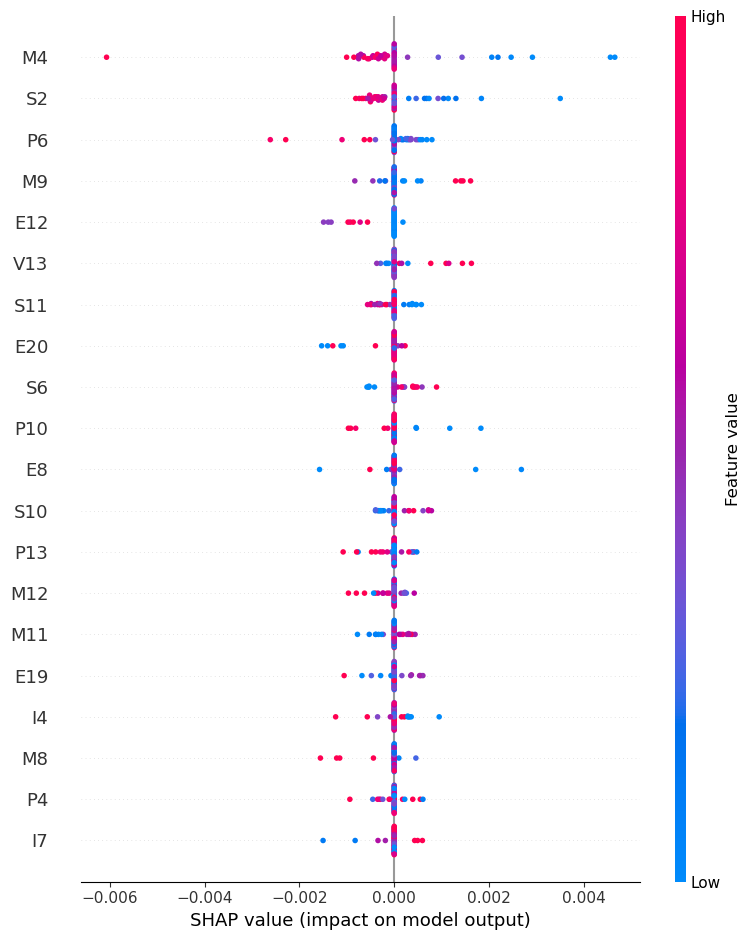

C:\Users\harsh\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(


In [13]:
import shap
from lime.lime_tabular import LimeTabularExplainer
import numpy as np
import matplotlib.pyplot as plt

# Use a small sample as background for KernelExplainer (to keep runtime reasonable)
background = X_train.sample(100, random_state=42)

# --- SHAP with KernelExplainer (slow but model-agnostic) ---

explainer = shap.KernelExplainer(model.predict, background)

# Use a small subset to explain to reduce compute time
sample_to_explain = X_train.sample(50, random_state=42)

shap_values = explainer.shap_values(sample_to_explain)

# Plot SHAP summary plot
shap.summary_plot(shap_values, sample_to_explain, show=True)

# Save SHAP plot if you want
plt.savefig("shap_histgradientboosting_summary.png", dpi=300, bbox_inches='tight')
plt.close()


# --- LIME for HistGradientBoosting ---

lime_explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns.tolist(),
    mode='regression'
)

# Pick a random instance to explain locally
idx = np.random.randint(0, len(X_train))
instance = X_train.iloc[idx]

lime_exp = lime_explainer.explain_instance(
    data_row=instance.values,
    predict_fn=model.predict,
    num_features=10
)

# Show inline (in Jupyter) or skip if running as script
lime_exp.show_in_notebook()

# Save explanation as HTML file
lime_exp.save_to_file("lime_histgradientboosting_explanation.html")
